<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Tareas%20y%20Actividades/AC14%20-%20LLM_Information_Extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

En esta notebook usaremos un LLM pequeño para extraer información de un texto no estructurado por medio de prompting. Para esto, usaremos [HuggingFace](https://huggingface.co).

🟨 **Debes conectarte en modo GPU**

# 1. Demo

El siguiente texto es parte de un artículo de Wikipedia sobre Leonhard Euler, matemático y físico. Queremos averiguar su fecha de nacimiento y su principal contribución científica. Cada una de estas piezas de información la almacenaras en una variable, por ejemplo `fecha_nacimiento` y `contribucion`. Al final, imprimiras cada variable.

In [ ]:
texto = '''Leonhard Paul Euler (pron. AFI: [ˈɔʏlɐ] en alemán moderno[2]​[3]​) (Basilea, Suiza, 15 de abril de 1707-San Petersburgo, Imperio ruso, 18 de septiembre de 1783), conocido como Leonhard Euler y llamado Leonardo Euler en español,[4]​ fue un matemático y físico suizo. Se trata del principal matemático del siglo XVIII y uno de los más grandes y prolíficos de todos los tiempos, muy conocido por el número de Euler (e), número que aparece en muchas fórmulas de cálculo y física.

Vivió en San Petersburgo (Rusia) y en Berlín (Prusia) la mayor parte de su vida adulta y realizó importantes descubrimientos en áreas tan diversas como el cálculo o la teoría de grafos. También introdujo gran parte de la terminología moderna y la notación matemática, particularmente para el área del análisis matemático, como, por ejemplo, la noción de función matemática.[5]​ Asimismo se le conoce por sus trabajos en los campos de la mecánica, la óptica y la astronomía.

Euler ha sido uno de los matemáticos más grandes, más prolíficos, y se calcula que sus obras completas reunidas podrían ocupar entre sesenta y ochenta volúmenes.[6]​ Una afirmación atribuida a Pierre-Simon Laplace expresa la influencia de Euler en los matemáticos posteriores: «Lean a Euler, lean a Euler, él es el maestro de todos nosotros»
'''

🔴 1. Copia el texto de arriba en la versión web de un LLM y haz un prompt para extraer ambas piezas de información. Considera que quieres tener **solamente** la información de fecha de nacimiento y principal contribución.

**Prompt**

Mediante el siguiente texto:


\<texto\>


Devuélveme únicamente dos variables de python llamadas "fecha_nacimiento" y "contribucion" en las que me digas la fecha de nacimiento de Leonhard Euler guardándola en la variable "fecha_nacimiento" y su principal contribución científica guardándola en la variable "contribución"

**Output**

In [ ]:
fecha_nacimiento = "15 de abril de 1707"

contribucion = "Desarrollo del número de Euler (e) y contribuciones fundamentales al cálculo, la teoría de grafos y la notación matemática moderna"

**Captura de pantalla**

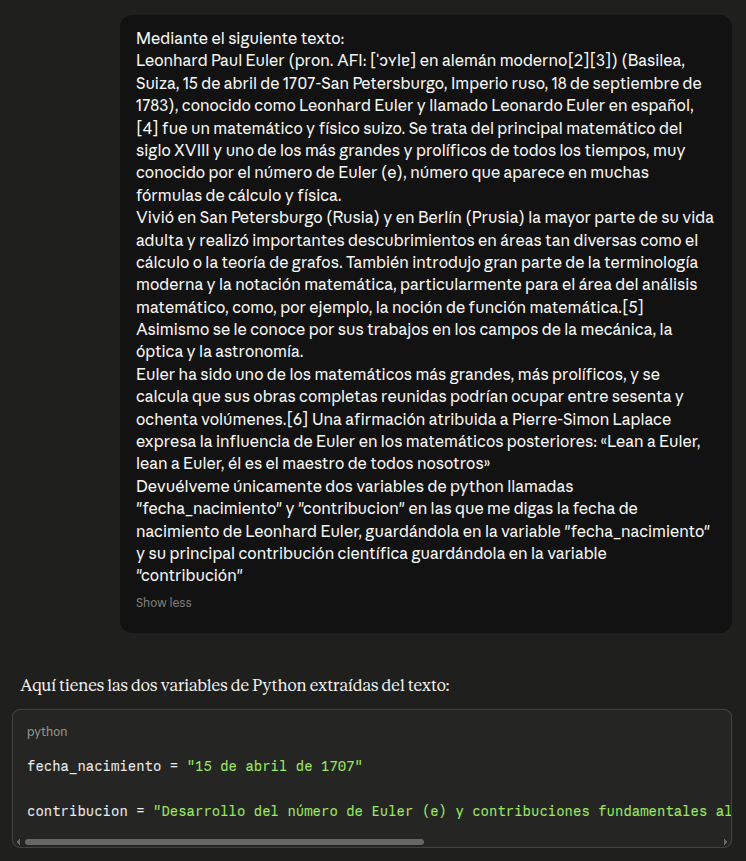

In [6]:
from IPython.display import Image, display

display(Image('./demo_1.png'))

🔴 2. Haz lo mismo que en el paso anterior, pero usando un LLM a traves de HuggingFace. Para esto, primero escoge un modelo de https://huggingface.co/models que sea **Instruct** y que sea pequeño <=10B de parámetros.

Puedes usar como referencia la notebook de prompting

In [1]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

🟢 Cargamos el tokenizador y modelo

In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

/home/Fer/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 339/339 [00:00<00:00, 652.59it/s]
Some parameters are on the meta device because they were offloaded to the cpu.


🔴 Define el prompt, incluye el texto a analizar

In [5]:
prompt = '''Mediante el siguiente texto:

Leonhard Paul Euler (pron. AFI: [ˈɔʏlɐ] en alemán moderno[2][3]) (Basilea, Suiza, 15 de abril de 1707-San Petersburgo, Imperio ruso, 18 de septiembre de 1783), conocido como Leonhard Euler y llamado Leonardo Euler en español,[4] fue un matemático y físico suizo. Se trata del principal matemático del siglo XVIII y uno de los más grandes y prolíficos de todos los tiempos, muy conocido por el número de Euler (e), número que aparece en muchas fórmulas de cálculo y física.
Vivió en San Petersburgo (Rusia) y en Berlín (Prusia) la mayor parte de su vida adulta y realizó importantes descubrimientos en áreas tan diversas como el cálculo o la teoría de grafos. También introdujo gran parte de la terminología moderna y la notación matemática, particularmente para el área del análisis matemático, como, por ejemplo, la noción de función matemática.[5] Asimismo se le conoce por sus trabajos en los campos de la mecánica, la óptica y la astronomía.
Euler ha sido uno de los matemáticos más grandes, más prolíficos, y se calcula que sus obras completas reunidas podrían ocupar entre sesenta y ochenta volúmenes.[6] Una afirmación atribuida a Pierre-Simon Laplace expresa la influencia de Euler en los matemáticos posteriores: «Lean a Euler, lean a Euler, él es el maestro de todos nosotros»

Devuélveme únicamente dos variables de python llamadas "fecha_nacimiento" y "contribucion" en las que me digas la fecha de nacimiento de Leonhard Euler guardándola en la variable "fecha_nacimiento" con formato "<month> <day>th, year"y su principal contribución científica guardándola en la variable "contribución"'''

🟢 Instruye al modelo para que extraiga la información

In [6]:
messages = [{"role": "user", "content": prompt}]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

# Generar respuesta
generated_ids = model.generate(
    **model_inputs,
    max_new_tokens=512,
    temperature=0.3,
    do_sample=True
)
output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
content = tokenizer.decode(output_ids, skip_special_tokens=True)

In [7]:
print(content)

```python
fecha_nacimiento = "April 15th, 1707"
contribucion = "Introducción de gran parte de la terminología moderna y la notación matemática, especialmente en el análisis matemático, y realización de importantes descubrimientos en áreas como el cálculo y la teoría de grafos."
```


🔴 Extrae la información de la respuesta del LLM. Estas variables deben tener **solamente** la información indicada.

✅ Correcto: `fecha_nacimiento = 'Febrary 30th, 1943'`

❎ Incorrecto: `fecha_nacimiento = 'Nació el 30 de febrero del año 1943'`

In [8]:
fecha_nacimiento = "April 15th, 1707"
contribucion = "Introducción de gran parte de la terminología moderna y la notación matemática, especialmente en el análisis matemático, y realización de importantes descubrimientos en áreas como el cálculo y la teoría de grafos."

🟢 Imprime la información


In [9]:
print(f"Fecha de nacimiento: {fecha_nacimiento}")
print(f"Contribución: {contribucion}")

Fecha de nacimiento: April 15th, 1707
Contribución: Introducción de gran parte de la terminología moderna y la notación matemática, especialmente en el análisis matemático, y realización de importantes descubrimientos en áreas como el cálculo y la teoría de grafos.


# 2. Práctica

Ahora hagamos lo mismo iterativamente con varios textos

🟢 Descargamos el dataset

In [10]:
!gdown 1Cn9vr88RUR4KEnWiP2LWqQinoGpBLjYP

Downloading...
From: https://drive.google.com/uc?id=1Cn9vr88RUR4KEnWiP2LWqQinoGpBLjYP
To: /home/Fer/Repos/TareasUnison/2026-1/PLN/Actividades/Actividad-14/wikipedia_InformationExtractionLLM.csv
100%|███████████████████████████████████████| 4.06k/4.06k [00:00<00:00, 877kB/s]


🟢 Leemos el corpus

In [6]:
import pandas as pd

df = pd.read_csv('wikipedia_InformationExtractionLLM.csv')
df = df[df['tipo']=='empresa']
df

,id,tipo,nombre,texto
0,1,empresa,NVIDIA,NVIDIA Corporation es una empresa de software ...
1,2,empresa,Airbnb,"Airbnb, es una compañía que ofrece una platafo..."
2,3,empresa,Samsung,Samsung Group o simplemente Samsung (estilizad...
3,4,empresa,Google,"Google LLC, más conocida como Google, es una e..."


🔴 Extrae la siguiente información de cada empresa de forma **iterativa**
 * Año de fundación
 * Fundadores
 * Actividad

 Añade columnas al dataframe en los respectivos renglones. **Usa lo desarrollado en el punto anterior**

In [4]:
model_name = "Qwen/Qwen2.5-7B-Instruct"

from transformers import AutoModelForCausalLM, AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype="auto",
    device_map="auto"
)

def extract_information(prompt):
    messages = [{"role": "user", "content": prompt}]
    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
    )
    model_inputs = tokenizer([text], return_tensors="pt").to(model.device)

    # Generar respuesta
    generated_ids = model.generate(
        **model_inputs,
        max_new_tokens=512,
        temperature=0.3,
        do_sample=True
    )
    output_ids = generated_ids[0][len(model_inputs.input_ids[0]):].tolist()
    content = tokenizer.decode(output_ids, skip_special_tokens=True)
    
    return content

Loading weights: 100%|██████████| 339/339 [00:00<00:00, 20655.29it/s]


🟢 Imprime la información recabada y añadida al dataframe original

In [16]:
import re

for brand in range(0, len(df)):
    prompt = f'Dado el siguiente texto: {df["texto"][brand]} Devuélveme únicamente tres variables llamadas "fundacion", "fundadores" y "actividad" en las que me digas el año de fundación de la empresa guardándola en la variable "fundacion", los nombres de los fundadores guardándolos en la variable "fundadores" y la actividad principal de la empresa guardándola en la variable "actividad". Imprime tu respuesta de tal froma que se vea <variable>: <resultado>'
    result = extract_information(prompt)
    print(result)
    
    print(f"----- {df['nombre'][brand]} -----\n")

    fundacion = re.search(r"fundacion:\s*(\d+)", result)
    fundacion = fundacion.group(1) if fundacion else None

    fundadores = re.search(r"fundadores:\s*(.+)", result)
    fundadores = fundadores.group(1) if fundadores else None

    actividad = re.search(r"actividad:\s*(.+)", result)
    actividad = actividad.group(1) if actividad else None

    df.at[brand, 'fundacion'] = fundacion
    df.at[brand, 'fundadores'] = fundadores
    df.at[brand, 'actividad'] = actividad

fundacion: 1993
fundadores: Jensen Huang, Chris Malachowsky, Curtis Priem
actividad: Desarrollo de unidades de procesamiento de gráficos (GPU), API para ciencia de datos y computación de alto rendimiento, y unidades de sistema en chip (SoC) para la computación móvil y el mercado automotriz.
----- NVIDIA -----

fundacion: 2008
fundadores: Brian Chesky, Joe Gebbia, Nathan Blecharczyk
actividad: Ofrece una plataforma digital para el alquiler vacacional de alojamientos a particulares y turísticos
----- Airbnb -----

fundacion: 1938
fundadores: Lee Byung-
actividad: electrónica de consumo, tecnología, finanzas, aseguradoras, construcción, biotecnología y sector servicios
----- Samsung -----

fundacion: 1998
fundadores: Larry Page, Sergey Brin
actividad: Inteligencia artificial, navegador inteligente, publicidad en línea, tecnología de motores de búsqueda, computación en la nube, software, computación cuántica, comercio electrónico y electrónica de consumo
----- Google -----



In [17]:
df

,id,tipo,nombre,texto,fundacion,fundadores,actividad
0,1,empresa,NVIDIA,NVIDIA Corporation es una empresa de software ...,1993,"Jensen Huang, Chris Malachowsky, Curtis Priem",Desarrollo de unidades de procesamiento de grá...
1,2,empresa,Airbnb,"Airbnb, es una compañía que ofrece una platafo...",2008,"Brian Chesky, Joe Gebbia, Nathan Blecharczyk",Ofrece una plataforma digital para el alquiler...
2,3,empresa,Samsung,Samsung Group o simplemente Samsung (estilizad...,1938,Lee Byung-,"electrónica de consumo, tecnología, finanzas, ..."
3,4,empresa,Google,"Google LLC, más conocida como Google, es una e...",1998,"Larry Page, Sergey Brin","Inteligencia artificial, navegador inteligente..."
